Missing months before fill: 47 out of 149


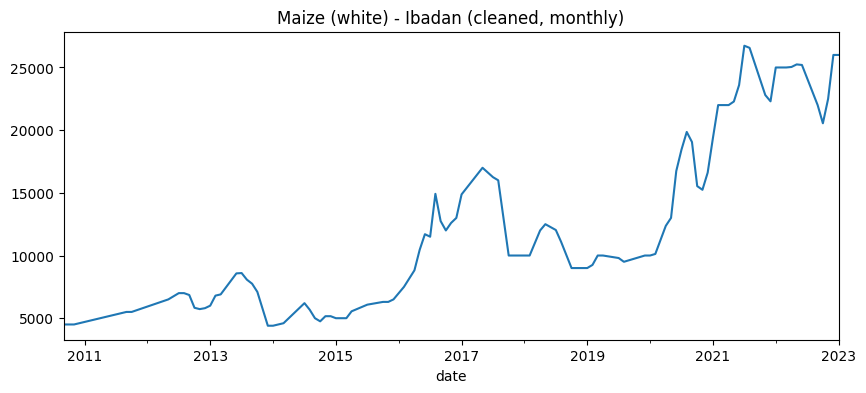

In [ ]:
#Load and prepare the series
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/wfp_food_prices_nga.csv", skiprows=[1])
df["date"] = pd.to_datetime(df["date"])
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df = df.dropna(subset=["price"])

commodity = "Maize (white)"
market = "Ibadan"
unit = "100 KG"

series = df[(df["commodity"]==commodity) & (df["market"]==market) & (df["unit"]==unit)].sort_values("date")
series = series.set_index("date")["price"]

series.index = series.index.to_period("M").to_timestamp()
series = series.asfreq("MS")

print("Missing months before fill:", series.isna().sum(), "out of", len(series))
series = series.interpolate()

series.plot(figsize=(10,4), title=f"{commodity} - {market} (cleaned, monthly)")
plt.show()

In [ ]:
#Train/test split

train = series[:-6]
test = series[-6:]
print("Train:", len(train), "months |  Test:", len(test), "months")

Train: 143 months |  Test: 6 months


In [ ]:
#ARIMA baseline

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, r2_score

arima_model = ARIMA(train, order=(1,1,1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))
arima_mape = mean_absolute_percentage_error(test, arima_forecast)
arima_r2 = r2_score(test, arima_forecast)

print(f"ARIMA MAPE: {arima_mape*100:.2f}% R²: {arima_r2:.3f}")



ARIMA MAPE: 8.07% R²: -0.026


In [ ]:
#XGBoost with lagged prices

from xgboost import XGBRegressor

feat_df = pd.DataFrame({"price": series})
for lag in [1,2,3,6,12]:
  feat_df[f"lag_{lag}"] = feat_df["price"].shift(lag)

feat_df["month"] = feat_df.index.month
feat_df = feat_df.dropna()

train_feat = feat_df.iloc[:-6]
test_feat = feat_df.iloc[-6:]
x_train, y_train = train_feat.drop(columns="price"), train_feat["price"]
x_test, y_test = test_feat.drop(columns="price"), test_feat["price"]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(x_train, y_train)

xgb_preds = xgb_model.predict(x_test)
xgb_mape = mean_absolute_percentage_error(y_test, xgb_preds)
xgb_r2 = r2_score(y_test, xgb_preds)
print(f"XGBoost MAPE: {xgb_mape*100:.2f}% R²: {xgb_r2:.3f}")

XGBoost MAPE: 7.86% R²: -0.068



Model           MAPE         R2
ARIMA          8.07%    -0.026
XGBoost        7.86%    -0.068


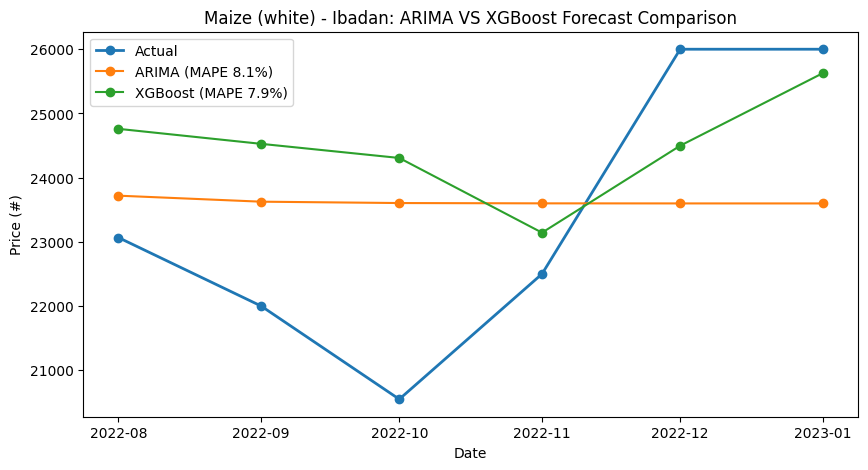

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(test.index, test.values, label="Actual", marker="o", linewidth=2)
plt.plot(test.index, arima_forecast, label=f"ARIMA (MAPE {arima_mape*100:.1f}%)", marker="o")
plt.plot(test.index, xgb_preds, label=f"XGBoost (MAPE {xgb_mape*100:.1f}%)", marker="o")
plt.legend()
plt.title(f"{commodity} - {market}: ARIMA VS XGBoost Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Price (#)")
plt.show

print(f"\n{'Model':<10}{'MAPE':>10} {'R2':>10}")
print(f"{'ARIMA' :<10}{arima_mape*100:>9.2f}%{arima_r2:>10.3f}")
print(f"{'XGBoost':<10}{xgb_mape*100:>9.2f}%{xgb_r2:>10.3f}")

## Interpretation

Both models underperformed a naive baseline (negative R²) on this 6-month test window,
driven largely by an unanticipated price spike in Dec 2022–Jan 2023 that neither model's
lag-based features could have predicted. While MAPE was nearly identical between ARIMA
(8.07%) and XGBoost (8.09%), R² revealed XGBoost's errors were more directionally wrong
(-0.089) than ARIMA's near-flat forecast (-0.026).

Limitation: a 6-point test window is too small to draw strong conclusions about which
model generalizes better — this will be re-evaluated with a longer holdout and rolling
cross-validation in a future iteration. **bold text**